Hi! I am a Kaggle beginner and not fluent in English, so this notebook is written in Japanese.

Please use your browser's translation (or DeepL/ChatGPT) to read it!

Hope it helps!

# これまでの進捗（簡易版）

| Ver. | 内容 | CV スコア | LB スコア | Time |
| ---- | ---- | ---- | ---- | ---- |
| 1 | LightGBM によるパイプライン構築 | 0.94128 | 0.94108 |  |
| 2 | EDA - commute_bin | 0.94129 | 0.94117 |  |
| 3 | EDA - income_bin | 0.94132 | 0.94117 |  |
| 4 | EDA - income_bin_x_subsidy | 0.94137 | 0.94123 |  |
| 5 | EDA - range_anxiety_num | 0.94138 | 0.94131 |  |
| 6 | EDA - env_minus_anxiety | 0.94142 | 0.94127 |  |
| 7 | EDA - env_x_anxiety_cat | 0.94146 | 0.94135 |  |
| 8 | ハイパーパラメータ調整 - max_depth | 0.94213 | 0.94216 |  |
| 11 | 実行環境の高速化 | 0.94212 | - | 3m 11s |
| 13 | EDA - スコアリング特徴量（Subsidy_Available, Environmental_Concern_Level） | 0.94214 | 0.94216 | 3m 26s（グラフ描画あり） |
| 14 | EDA - スコアリング特徴量（ミス発覚） | 0.94215 | 0.94215 | 3m 38s（グラフ描画あり） |

# ROC-AUC（ROC曲線下面積）について

今回の評価指標。　

- 予測値は「確率」を出力する

- 閾値に左右されない

In [1]:
import pandas as pd
import numpy as np

import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

path = kagglehub.competition_download("playground-series-s6e9")

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s6e9


In [3]:
train = pd.read_csv("../input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("../input/competitions/playground-series-s6e9/test.csv")
sample_submission = pd.read_csv("../input/competitions/playground-series-s6e9/sample_submission.csv")

# データの概要

今回の目的変数は `Will_Buy_EV`。

`train` は 668,665 件、`test` は 286,571 件。

データに欠損値なし。

## 各列の意味

参考 : https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety

- `id`
- `Age`
- `Annual_Income_USD` : 年間推定収入（米ドル）
- `Daily_Commute_km` : 1日あたりの通勤距離の推定値（km）
- `Number_of_Cars_Owned` : 購入者の世帯が現在所有している自動車の総台数
- `Charging_Stations_Near_Home` : 購入者の自宅付近にある公共充電ステーションの推定数
- `Charging_Stations_Near_Work` : 購入者の職場付近にある公共充電ステーションの推定数
- `Environmental_Concern_Level` : 環境への懸念レベル
- `Gender`
- `City_Type` : 購入者が居住している都市の種類（都市部、郊外、農村部）
- `Current_Car_Type` : 現在、主に運転している車の種類（セダン、SUV、ハッチバック、トラック）
- `Home_Charging_Possible` : 自宅充電が可能かどうか
- `Subsidy_Available` : 補助金利用が可能かどうか
- `Range_Anxiety_Level` : 航続距離への不安度

In [4]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [5]:
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [6]:
sample_submission.head()

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645


In [7]:
print(f"train の件数 = {len(train)}")
print(f"test の件数 = {len(test)}")
print(f"sample_submission の件数 = {len(sample_submission)}")

train の件数 = 668665
test の件数 = 286571
sample_submission の件数 = 286571


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           286571 non-null  int64  
 1   Age                          286571 non-null  int64  
 2   Annual_Income_USD            286571 non-null  float64
 3   Daily_Commute_km             286571 non-null  float64
 4   Number_of_Cars_Owned         286571 non-null  int64  
 5   Charging_Stations_Near_Home  286571 non-null  int64  
 6   Charging_Stations_Near_Work  286571 non-null  int64  
 7   Environmental_Concern_Level  286571 non-null  float64
 8   Gender                       286571 non-null  object 
 9   City_Type                    286571 non-null  object 
 10  Current_Car_Type             286571 non-null  object 
 11  Home_Charging_Possible       286571 non-null  object 
 12  Subsidy_Available            286571 non-null  object 
 13 

In [10]:
train[train["Daily_Commute_km"] >= 83]

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
3121,3121,66,76959.0,83.5,1,5,6,1.0,Male,Suburban,SUV,No,No,High,No
3557,3557,59,80777.0,88.2,2,2,2,2.0,Female,Rural,Sedan,No,Yes,High,No
3893,3893,41,117510.0,98.2,4,1,2,1.0,Female,Rural,Sedan,No,Yes,High,No
7921,7921,54,30000.0,90.6,2,1,6,3.0,Female,Suburban,Truck,No,Yes,High,No
14162,14162,53,85464.0,88.5,1,7,3,4.0,Female,Suburban,Sedan,No,No,High,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638568,638568,48,94069.0,85.3,1,4,1,1.0,Male,Suburban,SUV,No,No,High,No
643090,643090,36,75797.0,88.0,2,0,2,1.0,Female,Suburban,SUV,No,No,High,No
653352,653352,47,30000.0,96.6,2,4,1,3.0,Male,Suburban,Sedan,No,Yes,High,No
658407,658407,47,96593.0,88.9,1,2,6,2.0,Male,Suburban,SUV,No,No,High,No


# 関数の定義

## ハイパーパラメータ

- `max_depth` : 3 が底。2 ～ 3 個の変数の組み合わせが限界、それ以上は過学習する。
- `num_leaves` : `max_depth` に対応。

In [11]:
def train_lgb(train_df, test_df, feature_cols, target_col="Will_Buy_EV"):
    """
    指定された特徴量で LightGBM の交差検証学習を行い、
    OOF予測値（確率）、テスト予測値（確率）、学習済みモデル群を返す関数
    """
    # 1. 目的変数の変換
    y_train = (train_df[target_col] == "Yes").astype(int).values # NumPy配列にして高速化
    
    # 【高速化①】ループの前にカテゴリ型への一括変換を済ませる
    X_train_df = train_df[feature_cols].copy()
    X_test_df = test_df[feature_cols].copy()
    
    for col in feature_cols:
        if X_train_df[col].dtype == 'object':
            X_train_df[col] = X_train_df[col].astype('category')
            X_test_df[col] = X_test_df[col].astype('category')

    # 【高速化②】.iloc のオーバーヘッドを避けるため、一回 pandas のままではなく 
    # LightGBM が最も得意とする DataFrame/NumPy の構造を維持する
    X_train_df = X_train_df.reset_index(drop=True)

    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'max_depth': 3,
        'num_leaves': 8,
        'learning_rate': 0.1,
        # 'max_bin': 31,

        # 🚀 過学習防止 & 高速化（ランダム性の導入）
        'colsample_bytree': 0.8,
        # 'subsample': 0.8,
        # 'subsample_freq': 1, # 💡 subsampleを動かす時は、1イテレーションごとにサンプリングし直すこの指定をセットで入れる
        
        'n_jobs': -1,  # 全コア並列使用
        'random_state': 0,
        'verbose': -1,
        'enable_categorical': True,

        # 🚀 GPUを使用するための設定
        # 'device_type': 'gpu',
        # 'gpu_use_dp': False,  # 必ず False（単精度/float32）にする。倍精度(True)は極端に遅くなります
    }

    models = []
    oof_train = np.zeros(len(X_train_df))

    # 💡 ループ内での y_preds への append は廃止
    
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train_df, y_train)):
        # 【高速化③】iloc のスライスを最小限に
        X_tr = X_train_df.iloc[train_idx]
        y_tr = y_train[train_idx]
        X_va = X_train_df.iloc[valid_idx]
        y_va = y_train[valid_idx]

        # Datasetの作成 (free_raw_data=True でメモリを節約)
        lgb_train = lgb.Dataset(X_tr, y_tr, free_raw_data=True)
        lgb_eval = lgb.Dataset(X_va, y_va, reference=lgb_train, free_raw_data=True)

        # モデルの学習
        model = lgb.train(
            params,
            lgb_train,
            valid_sets=[lgb_eval], # lgb_train を削除して検証データのみにする
            num_boost_round=1500,  # デフォルトは 1000 あたり

            # stopping_rounds のデフォルトは 100 あたり
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        best_iter = model.best_iteration
        best_score = model.best_score['valid_0']['auc']
        print(f"Fold {fold+1} | Best Iteration: {best_iter:4d} | Best AUC: {best_score:.5f}")

        # 検証データの予測
        oof_train[valid_idx] = model.predict(X_va, num_iteration=model.best_iteration)
        
        # 💡　test_df の予測処理を削除し、モデルの保存だけに限定
        models.append(model)

    # 全体の OOF ROC-AUC スコアを計算
    score = roc_auc_score(y_train, oof_train)
    print(f"OOF ROC-AUC Score: {score:.5f}")

    # 💡 すべての学習が終わった後、ループの外でテストデータを一括予測する
    print("\nLoop finished. Predicting test data...")
    y_preds = [model.predict(X_test_df, num_iteration=model.best_iteration) for model in models]
    y_preds_mean = np.mean(y_preds, axis=0)

    return oof_train, y_preds_mean, models


In [12]:
def plot_feature_importance(importance_df, top_n=20):
    """
    特徴量重要度のデータフレームを受け取り、上位 top_n 件を横棒グラフで描画する関数
    """
    plt.figure(figsize=(10, 8))
    
    # y軸に特徴量名（feature）、x軸に重要度（importance）を指定
    sns.barplot(
        x='importance',
        y='feature',
        data=importance_df.head(top_n),
        palette='viridis',
        hue='feature',
        legend=False
    )
    
    plt.title(f'LightGBM Feature Importance (Top {top_n})')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

# EDA

## binning

### commute_bin

通勤距離のビン分け

(array([1.45351e+05, 2.29300e+03, 6.78900e+03, 1.54040e+04, 1.81820e+04,
        3.16810e+04, 3.14390e+04, 3.55890e+04, 4.30330e+04, 3.59820e+04,
        3.87270e+04, 3.33400e+04, 3.84700e+04, 4.54400e+04, 3.56580e+04,
        3.57410e+04, 2.76220e+04, 2.16850e+04, 9.29900e+03, 7.35800e+03,
        6.17100e+03, 1.71400e+03, 8.96000e+02, 5.82000e+02, 3.40000e+01,
        4.80000e+01, 7.60000e+01, 1.90000e+01, 1.00000e+00, 4.10000e+01]),
 array([ 5.        ,  8.12333333, 11.24666667, 14.37      , 17.49333333,
        20.61666667, 23.74      , 26.86333333, 29.98666667, 33.11      ,
        36.23333333, 39.35666667, 42.48      , 45.60333333, 48.72666667,
        51.85      , 54.97333333, 58.09666667, 61.22      , 64.34333333,
        67.46666667, 70.59      , 73.71333333, 76.83666667, 79.96      ,
        83.08333333, 86.20666667, 89.33      , 92.45333333, 95.57666667,
        98.7       ]),
 <BarContainer object of 30 artists>)

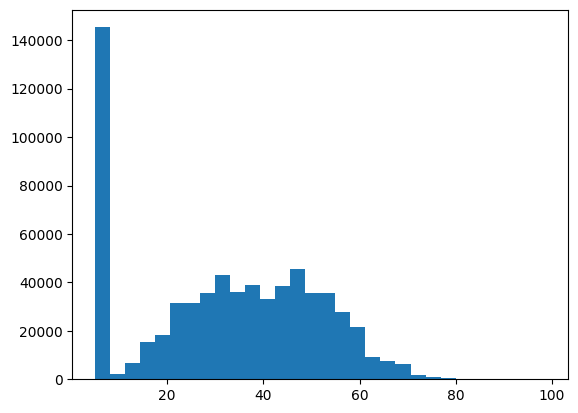

In [13]:
plt.hist(train["Daily_Commute_km"], bins=30)

In [14]:
# 通勤距離のビン分け（範囲の定義）
# 0〜8km（5kmの大量データ含む）、8〜20km、20〜60km（中距離）、60〜80km（長距離）、80km〜（超長距離）
bins = [0, 8, 20, 60, 80, float('inf')]
labels = ['short_5km_zone', 'short_mid', 'mid_distance', 'long_distance', 'super_long_distance']

# pd.cut でカテゴリ変数化（LGBMで直接扱えるように category 型にキャスト）
train['commute_bin'] = pd.cut(train['Daily_Commute_km'], bins=bins, labels=labels).astype('category')
test['commute_bin'] = pd.cut(test['Daily_Commute_km'], bins=bins, labels=labels).astype('category')

### income_bin

年収のビン分け

(array([6.1607e+04, 8.8100e+02, 3.9340e+03, 9.5540e+03, 2.1099e+04,
        2.9093e+04, 4.0730e+04, 3.6918e+04, 5.1206e+04, 5.1907e+04,
        6.1279e+04, 5.5080e+04, 5.6294e+04, 3.0584e+04, 3.2445e+04,
        2.4829e+04, 1.8902e+04, 3.0063e+04, 1.0269e+04, 1.6962e+04,
        7.4760e+03, 6.0590e+03, 5.1300e+03, 3.2340e+03, 1.0540e+03,
        1.1430e+03, 7.7300e+02, 1.1700e+02, 3.3000e+01, 1.0000e+01]),
 array([ 30000.        ,  35284.96666667,  40569.93333333,  45854.9       ,
         51139.86666667,  56424.83333333,  61709.8       ,  66994.76666667,
         72279.73333333,  77564.7       ,  82849.66666667,  88134.63333333,
         93419.6       ,  98704.56666667, 103989.53333333, 109274.5       ,
        114559.46666667, 119844.43333333, 125129.4       , 130414.36666667,
        135699.33333333, 140984.3       , 146269.26666667, 151554.23333333,
        156839.2       , 162124.16666667, 167409.13333333, 172694.1       ,
        177979.06666667, 183264.03333333, 188549.        ]

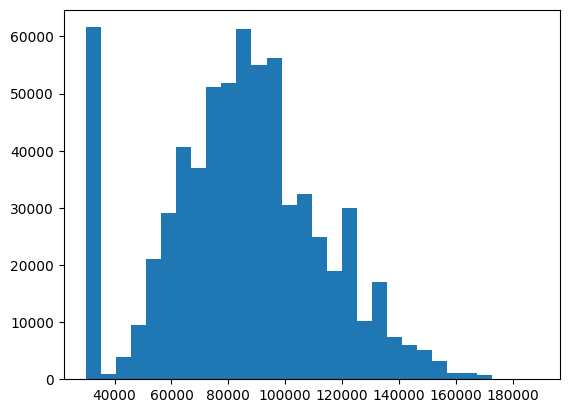

In [15]:
plt.hist(train["Annual_Income_USD"], bins=30)

In [16]:
income_bins = [0, 30000, 60000, 100000, 150000, float('inf')]
income_labels = ['income_min_30k', 'low_income', 'mid_income', 'high_income', 'super_high_income']

train['income_bin'] = pd.cut(train['Annual_Income_USD'], bins=income_bins, labels=income_labels).astype('category')
test['income_bin'] = pd.cut(test['Annual_Income_USD'], bins=income_bins, labels=income_labels).astype('category')

## income_bin_x_subsidy

年収 × 補助金の有無

In [17]:
# カテゴリ同士を文字列で結合（例: "low_income_Yes", "high_income_No"）
train['income_bin_x_subsidy'] = (train['income_bin'].astype(str) + '_' + train['Subsidy_Available'].astype(str)).astype('category')
test['income_bin_x_subsidy'] = (test['income_bin'].astype(str) + '_' + test['Subsidy_Available'].astype(str)).astype('category')

## range_anxiety_num

`Range_Anxiety_Level` の数値化

In [18]:
train["Range_Anxiety_Level"].value_counts()

Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64

In [19]:
anxiety_map = {'Low': 1, 'Medium': 2, 'High': 3}

train['range_anxiety_num'] = train['Range_Anxiety_Level'].map(anxiety_map)
test['range_anxiety_num'] = test['Range_Anxiety_Level'].map(anxiety_map)

## env_minus_anxiety

環境意識 × 不安度（心理的バランス）

In [20]:
train["Environmental_Concern_Level"].describe()

count    668665.000000
mean          2.935477
std           1.429119
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Environmental_Concern_Level, dtype: float64

In [21]:
# "5.0_Low", "1.0_High" のような 15 通りの組み合わせを作成
train['env_x_anxiety_cat'] = (train['Environmental_Concern_Level'].astype(str) + '_' + train['Range_Anxiety_Level'].astype(str)).astype('category')
test['env_x_anxiety_cat'] = (test['Environmental_Concern_Level'].astype(str) + '_' + test['Range_Anxiety_Level'].astype(str)).astype('category')

## Charging_Convenience

In [22]:
train["Charging_Convenience"] = train["Charging_Stations_Near_Home"] + train["Charging_Stations_Near_Work"]
test["Charging_Convenience"] = test["Charging_Stations_Near_Home"] + test["Charging_Stations_Near_Work"]

## income_per_car

In [23]:
# 0 除算を防ぐため np.where を使用（0台の場合はそのまま年収、または np.nan / 特定値に）
train['income_per_car'] = train['Annual_Income_USD'] / np.where(
    train['Number_of_Cars_Owned'] == 0, 1, train['Number_of_Cars_Owned']
)
test['income_per_car'] = test['Annual_Income_USD'] / np.where(
    test['Number_of_Cars_Owned'] == 0, 1, test['Number_of_Cars_Owned']
)

In [24]:
# 居住地 × 現在の車タイプ を結合
# train['city_x_car_type'] = (
#     train['City_Type'].astype(str) + '_' + train['Current_Car_Type'].astype(str)
# ).astype('category')
# test['city_x_car_type'] = (
#     test['City_Type'].astype(str) + '_' + test['Current_Car_Type'].astype(str)
# ).astype('category')

In [25]:
# 車種ごとの推定燃費（相対的なガソリン消費係数）を設定
# Truck/SUV は燃費が悪い(1.5~1.8)、Hatchback は良い(1.0)
# car_fuel_factor = {'Hatchback': 1.0, 'Sedan': 1.2, 'SUV': 1.5, 'Truck': 1.8}

# train['fuel_cost_factor'] = (
#     train['Current_Car_Type'].map(car_fuel_factor) * train['Daily_Commute_km']
# )
# test['fuel_cost_factor'] = (
#     test['Current_Car_Type'].map(car_fuel_factor) * test['Daily_Commute_km']
# )

## 不採用

- 通勤距離の5km、超長距離フラグ
- 年齢のビン分け × 年収のビン分け
- `Environmental_Concern_Level` が 5.0（最高）かどうかをフラグ化

In [26]:
# # 1. 5kmフラグと長距離（83km以上など）フラグ
# train['is_commute_5.0'] = (train['Daily_Commute_km'] == 5.0).astype(int)
# test['is_commute_5.0'] = (test['Daily_Commute_km'] == 5.0).astype(int)

# train['is_commute_over_83'] = (train['Daily_Commute_km'] >= 83).astype(int)
# test['is_commute_over_83'] = (test['Daily_Commute_km'] >= 83).astype(int)

# # 2. 通勤距離あたりの充電スタンド比率（0除算防止で+1）
# # 自宅付近のスタンドとの比率
# train['commute_per_home_station'] = train['Daily_Commute_km'] / (train['Charging_Stations_Near_Home'] + 1)
# test['commute_per_home_station'] = test['Daily_Commute_km'] / (test['Charging_Stations_Near_Home'] + 1)

# # 職場付近のスタンドとの比率（★ここを追加・修正）
# train['commute_per_work_station'] = train['Daily_Commute_km'] / (train['Charging_Stations_Near_Work'] + 1)
# test['commute_per_work_station'] = test['Daily_Commute_km'] / (test['Charging_Stations_Near_Work'] + 1)

# # 自宅＋職場の合計スタンド数に対する比率
# train['commute_per_total_station'] = train['Daily_Commute_km'] / (train['Charging_Convenience'] + 1)
# test['commute_per_total_station'] = test['Daily_Commute_km'] / (test['Charging_Convenience'] + 1)

In [27]:
# 通勤距離あたりの充電スタンド比率（0除算防止で+1）
# 自宅 + 職場の合計スタンド数に対する比率
# train['commute_per_home_station'] = train['Daily_Commute_km'] / (train['Charging_Stations_Near_Home'] + train['Charging_Stations_Near_Work'] + 1)
# test['commute_per_home_station'] = test['Daily_Commute_km'] / (test['Charging_Stations_Near_Home'] + test['Charging_Stations_Near_Work']  + 1)

In [28]:
# train["Dependence_Work"] = train["Charging_Stations_Near_Work"] / (train["Charging_Stations_Near_Home"] + 1)
# test["Dependence_Work"] = test["Charging_Stations_Near_Work"] / (test["Charging_Stations_Near_Home"] + 1)

In [29]:
# # 10 歳区切り
# age_bins = [0, 34, 44, 54, 64, float('inf')]
# age_labels = ['young', 'early_mid', 'late_mid', 'pre_senior', 'senior']

# train['age_bin'] = pd.cut(train['Age'], bins=age_bins, labels=age_labels).astype('category')
# test['age_bin'] = pd.cut(test['Age'], bins=age_bins, labels=age_labels).astype('category')

# # age_bin × income_bin のカテゴリ結合
# # "late_mid_high_income" のような 25 通りの組み合わせを作成
# train['age_x_income_cat'] = (train['age_bin'].astype(str) + '_' + train['income_bin'].astype(str)).astype('category')
# test['age_x_income_cat'] = (test['age_bin'].astype(str) + '_' + test['income_bin'].astype(str)).astype('category')

In [30]:
# # Environmental_Concern_Level が 5.0（最高）かどうかをフラグ化
# train['is_env_top'] = (train['Environmental_Concern_Level'] == 5.0).astype(int)
# test['is_env_top'] = (test['Environmental_Concern_Level'] == 5.0).astype(int)

In [31]:
# # 3 区分のラベルを作成
# def categorize_env(val):
#     if val == 5.0:
#         return 'top_5'
#     elif val == 4.0:
#         return 'high_4'
#     else:
#         return 'low_3_or_less'

# train['env_concern_group'] = train['Environmental_Concern_Level'].apply(categorize_env).astype('category')
# test['env_concern_group'] = test['Environmental_Concern_Level'].apply(categorize_env).astype('category')

In [32]:
# 0除算を防ぐため np.where を使用（所有台数が 0 台の場合はそのまま Daily_Commute_km を使用）
# train['commute_km_per_car'] = train['Daily_Commute_km'] / np.where(
#     train['Number_of_Cars_Owned'] == 0, 1, train['Number_of_Cars_Owned']
# )
# test['commute_km_per_car'] = test['Daily_Commute_km'] / np.where(
#     test['Number_of_Cars_Owned'] == 0, 1, test['Number_of_Cars_Owned']
# )

In [33]:
# 全体（Home + Work）のうち、自宅周辺が占める割合
# 1e-5 を分母に足して、ゼロ除算を防ぐ
# train['home_charging_ratio'] = train['Charging_Stations_Near_Home'] / (
#     train['Charging_Convenience'] + 1e-5
# )
# test['home_charging_ratio'] = test['Charging_Stations_Near_Home'] / (
#     test['Charging_Convenience'] + 1e-5
# )

## スコアリング特徴量

全体購入率 17.5% を基準に閾値を決める。
25% 以上（全体購入率の 1.4 倍以上）から、購入率が高いと設定。

In [34]:
target_cols = [
    "Number_of_Cars_Owned",
    "Environmental_Concern_Level",
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "commute_bin",
    "income_bin",
    "income_bin_x_subsidy",
    "range_anxiety_num",
    "env_x_anxiety_cat",
]

In [35]:
def show_buy_rate_fast(df, col, target_col='Will_Buy_EV'):
    """メモリ効率と処理速度を最適化した購入率集計関数"""
    
    # ターゲットの数値化（一時的なコピーを作らず計算）
    y = (df[target_col] == 'Yes').astype(np.int8)

    # 集計処理（observed=Trueで無駄なグループ作成を防止）
    res = (
        df.groupby(col, observed=True)[target_col]
        .agg(
            件数='count',
            購入率_pct=lambda x: (x == 'Yes').mean() * 100,
        )
        .reset_index()
    )

    res['購入率 (%)'] = res['購入率_pct'].round(1).astype(str) + '%'
    
    return res.drop(columns=['購入率_pct'])


# 1行ずつ安全に出力
for col in target_cols:
    if col in train.columns:
        print(f'=== 【{col}】の値別データ件数と購入率 ===')
        display(show_buy_rate_fast(train, col))
        print('-' * 40)

=== 【Number_of_Cars_Owned】の値別データ件数と購入率 ===


,Number_of_Cars_Owned,件数,購入率 (%)
0,1,288012,17.1%
1,2,298287,17.8%
2,3,68877,17.5%
3,4,13489,16.6%


----------------------------------------
=== 【Environmental_Concern_Level】の値別データ件数と購入率 ===


,Environmental_Concern_Level,件数,購入率 (%)
0,1.0,147476,0.6%
1,2.0,135133,2.1%
2,3.0,127351,11.1%
3,4.0,130469,24.9%
4,5.0,128236,51.8%


----------------------------------------
=== 【Gender】の値別データ件数と購入率 ===


...

----------------------------------------
=== 【range_anxiety_num】の値別データ件数と購入率 ===


,range_anxiety_num,件数,購入率 (%)
0,1,603972,18.9%
1,2,62499,4.2%
2,3,2194,0.1%


----------------------------------------
=== 【env_x_anxiety_cat】の値別データ件数と購入率 ===


,env_x_anxiety_cat,件数,購入率 (%)
0,1.0_High,614,0.0%
1,1.0_Low,131130,0.6%
2,1.0_Medium,15732,0.1%
3,2.0_High,509,0.0%
4,2.0_Low,120478,2.4%
5,2.0_Medium,14146,0.4%
6,3.0_High,438,0.0%
7,3.0_Low,114784,12.0%
8,3.0_Medium,12129,2.5%
9,4.0_High,406,0.0%


----------------------------------------


In [36]:
# 1. プラス要素のカウント（購入率 25% 以上の条件）
train['Pos_score'] = 0
test['Pos_score'] = 0

# ゆるいプラス条件（購入率 25 ~ 35%） -> +1 点
train['Pos_score'] += (train['Subsidy_Available'] == 'Yes').astype(int) * 1
test['Pos_score'] += (test['Subsidy_Available'] == 'Yes').astype(int) * 1
train['Pos_score'] += (train['Environmental_Concern_Level'] == 4.0).astype(int) * 1
test['Pos_score'] += (test['Environmental_Concern_Level'] == 4.0).astype(int) * 1
train['Pos_score'] += (train['commute_bin'] == 'short_mid').astype(int) * 1
test['Pos_score'] += (test['commute_bin'] == 'short_mid').astype(int) * 1
train['Pos_score'] += (train['income_bin'] == 'high_income').astype(int) * 1
test['Pos_score'] += (test['income_bin'] == 'high_income').astype(int) * 1
train['Pos_score'] += (train['env_x_anxiety_cat'] == '4.0_Low').astype(int) * 1
test['Pos_score'] += (test['env_x_anxiety_cat'] == '4.0_Low').astype(int) * 1

# 強力なプラス条件（購入率 35 ~ 50%） -> +2 点
train['Pos_score'] += (train['income_bin'] == 'super_high_income').astype(int) * 2
test['Pos_score'] += (test['income_bin'] == 'super_high_income').astype(int) * 2

# 非常に強力なプラス条件（購入率 50% 以上） -> +3 点
train['Pos_score'] += (train['Environmental_Concern_Level'] == 5.0).astype(int) * 3
test['Pos_score'] += (test['Environmental_Concern_Level'] == 5.0).astype(int) * 3
train['Pos_score'] += (train['env_x_anxiety_cat'] == '5.0_Low').astype(int) * 3
test['Pos_score'] += (test['env_x_anxiety_cat'] == '5.0_Low').astype(int) * 3


# 2. マイナス要素のカウント（購入率が極端に低い 10% 未満の条件）
train['Neg_score'] = 0
test['Neg_score'] = 0
low_income_list = ["income_min_30k", "low_income"]

train['Neg_score'] += (train['Subsidy_Available'] == 'No').astype(int) * 1
test['Neg_score'] += (test['Subsidy_Available'] == 'No').astype(int) * 1
train['Neg_score'] += (train['Environmental_Concern_Level'] <= 2.0).astype(int) * 1
test['Neg_score'] += (test['Environmental_Concern_Level'] <= 2.0).astype(int) * 1
train['Neg_score'] += (train['range_anxiety_num'] >= 2.0).astype(int) * 1
test['Neg_score'] += (test['range_anxiety_num'] >= 2.0).astype(int) * 1
train['Neg_score'] += (train['income_bin'].isin(low_income_list)).astype(int) * 1
test['Neg_score'] += (test['income_bin'].isin(low_income_list)).astype(int) * 1


# 3. プラス要素とマイナス要素の差分
train['Total_score'] = train['Pos_score'] - train['Neg_score']
test['Total_score'] = test['Pos_score'] - test['Neg_score']

In [37]:
# # 1. プラス要素のカウント（購入率 25%~30% 以上の条件）
# train['pos_score'] = 0
# train['pos_score'] += (train['Subsidy_Available'] == 'Yes').astype(int) * 2  # 30%超の強条件は2点など
# train['pos_score'] += (train['Home_Charging_Possible'] == 'Yes').astype(int) * 1
# train['pos_score'] += (train['commute_bin'] == 'short_mid').astype(int) * 1

# # 2. マイナス要素のカウント（購入率が極端に低い 10% 未満などの条件）
# train['neg_score'] = 0
# train['neg_score'] += (train['Subsidy_Available'] == 'No').astype(int) * 2  # ほぼ買わない条件
# train['neg_score'] += (train['Environmental_Concern_Level'] <= 1.0).astype(int) * 1

# # ※必要であれば、最後に「差分（pos - neg）」を 3 つ目の特徴量として足すのもアリです
# train['net_score'] = train['pos_score'] - train['neg_score']

# クラスタリング

In [38]:
binary_map = {'Yes': 1, 'No': 0}

# train の変換
train['Home_Charging_Possible_num'] = (
    train['Home_Charging_Possible'].map(binary_map).astype(int)
)
train['Subsidy_Available_num'] = (
    train['Subsidy_Available'].map(binary_map).astype(int)
)

# test の変換
test['Home_Charging_Possible_num'] = (
    test['Home_Charging_Possible'].map(binary_map).astype(int)
)
test['Subsidy_Available_num'] = (
    test['Subsidy_Available'].map(binary_map).astype(int)
)

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. クラスタリングに使う数値特徴量を選択
cluster_features = [
    'Annual_Income_USD',
    'Daily_Commute_km',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work',
    'Environmental_Concern_Level',
    'Number_of_Cars_Owned',
    'Age',
    'range_anxiety_num',
    'Charging_Convenience',
    'Home_Charging_Possible_num',
    'Subsidy_Available_num',
]

# 2. スケーリング（StandardScaler で標準化：k-means に必須）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[cluster_features])
X_test_scaled = scaler.transform(test[cluster_features])

# 3. k-means で 10 クラスタに分類（最初は 8 くらいから試す）
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
train['cluster_id'] = kmeans.fit_predict(X_train_scaled)
test['cluster_id'] = kmeans.predict(X_test_scaled)

# 4. LightGBM で扱えるように category 型に変換
train['cluster_id'] = train['cluster_id'].astype('category')
test['cluster_id'] = test['cluster_id'].astype('category')

# 実行

Fold 1 | Best Iteration: 1003 | Best AUC: 0.94144
Fold 2 | Best Iteration:  953 | Best AUC: 0.94167
Fold 3 | Best Iteration: 1084 | Best AUC: 0.94226
Fold 4 | Best Iteration: 1046 | Best AUC: 0.94150
Fold 5 | Best Iteration: 1297 | Best AUC: 0.94380
OOF ROC-AUC Score: 0.94212

Loop finished. Predicting test data...
🔥 Final CV ROC-AUC Score: 0.94212



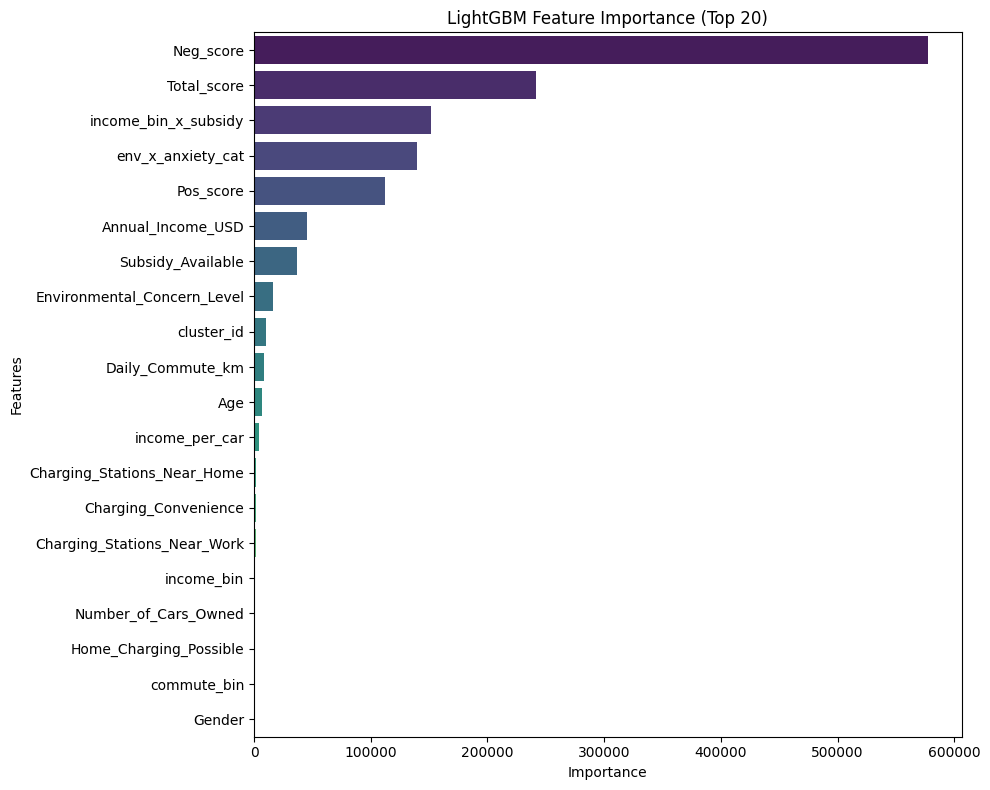

CPU times: user 13min 7s, sys: 1.39 s, total: 13min 9s
Wall time: 3min 21s


In [40]:
%%time

# 1. 不要な列の除外（特徴量の選択）
features = [
    col
    for col in train.columns
    if col not in [
    "id",
    "Will_Buy_EV",
    "Range_Anxiety_Level",
    'range_anxiety_num',
    'age_bin',
    'Home_Charging_Possible_num',
    'Subsidy_Available_num',
    'City_Type',
    'Current_Car_Type',
    ]
]

# 2. 【型変換の一括適用】Daily_Commute_kmの100倍整数化と、各列の型軽量化
train_copy = train.copy()
test_copy = test.copy()

# ① Daily_Commute_km を100倍して丸める
if 'Daily_Commute_km' in features:
    train_copy['Daily_Commute_km'] = (train_copy['Daily_Commute_km'] * 100).round()
    test_copy['Daily_Commute_km'] = (test_copy['Daily_Commute_km'] * 100).round()

# ② 辞書型を用いて一括型キャスト
type_mapping = {}
for col in features:
    if train_copy[col].dtype == 'object':
        type_mapping[col] = 'category'
    elif col in ['Annual_Income_USD', 'Daily_Commute_km']:
        type_mapping[col] = 'int32'
    elif col == 'Environmental_Concern_Level':
        type_mapping[col] = 'int16'

train_copy = train_copy.astype(type_mapping)
test_copy = test_copy.astype(type_mapping)


# 3. 余計な列を完全に排除した「純粋な軽量DataFrame」を孤立させて作成
pure_train = train_copy[features + ["Will_Buy_EV"]].copy()
pure_test = test_copy[features].copy()


# 4. 学習の実行（軽量化した pure_train / pure_test を投入）
oof_train, y_preds, models = train_lgb(pure_train, pure_test, features)


# 5. 正解ラベルの数値化と全体の OOF ROC-AUC スコアの計算
y_true = (pure_train["Will_Buy_EV"] == "Yes").astype(int)
cv_auc = roc_auc_score(y_true, oof_train)
print(f"🔥 Final CV ROC-AUC Score: {cv_auc:.5f}\n")


# 6. 特徴量重要度の可視化
feature_importances = np.mean(
    [model.feature_importance(importance_type="gain") for model in models],
    axis=0,
)

importance_df = pd.DataFrame(
    {"feature": features, "importance": feature_importances}
).sort_values("importance", ascending=False).reset_index(drop=True)

plot_feature_importance(importance_df, top_n=20)

## ベストスコア

Fold 1 - Best AUC: 0.94147
 
Fold 2 - Best AUC: 0.94169
 
Fold 3 - Best AUC: 0.94227

Fold 4 - Best AUC: 0.94154

Fold 5 - Best AUC: 0.94386
 
OOF ROC-AUC Score: 0.94215

3m 38s（グラフ描画あり）

# エラー分析

モデルが間違えたデータを観察する。

In [41]:
# 1. 目的変数の数値化 (Yes=1, No=0)
y_true = (train["Will_Buy_EV"] == "Yes").astype(int)

# 2. エラー（絶対誤差）の計算
# oof_train には train_lgb 関数から返された OOF 予測確率が入っている前提
error = np.abs(y_true - oof_train)

# 3. 分析用データフレームの作成
df_error = train.copy()
df_error["oof_pred"] = oof_train
df_error["error"] = error

# --- A. 偽陰性（False Negative）の抽出 ---
# 「実際は購入した (Will_Buy_EV == Yes)」のに「予測確率が非常に低い (例: < 0.2)」データ
fn_df = df_error[(y_true == 1) & (df_error["oof_pred"] <= 0.15)].sort_values(
    "error", ascending=False
)

# --- B. 偽陽性（False Positive）の抽出 ---
# 「実際は購入していない (Will_Buy_EV == No)」のに「予測確率が非常に高い (例: > 0.8)」データ
fp_df = df_error[(y_true == 0) & (df_error["oof_pred"] >= 0.4)].sort_values(
    "error", ascending=False
)

print(f"大きく外した件数 -> 偽陰性(FN): {len(fn_df)} 件, 偽陽性(FP): {len(fp_df)} 件")

大きく外した件数 -> 偽陰性(FN): 8679 件, 偽陽性(FP): 41808 件


## 偽陰性（False Negative）

買ったのに低い確率が出た（モデルの見落とし・隠れた後押し要因）

In [42]:
# 実際は買ったのにモデルが買わないと予測した人たちの特徴を確認

# features（学習に使った全特徴量のリスト）に 'oof_pred' を追加して表示
display_cols = features + ['oof_pred']

# 偽陰性（FN）上位 10 件を表示
fn_df[display_cols].head(10)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,Home_Charging_Possible,Subsidy_Available,...,income_bin,income_bin_x_subsidy,env_x_anxiety_cat,Charging_Convenience,income_per_car,Pos_score,Neg_score,Total_score,cluster_id,oof_pred
513302,65,30000.0,28.2,2,2,3,2.0,Male,Yes,No,...,income_min_30k,income_min_30k_No,2.0_Low,5,15000.00,0,3,-3,4,0.000009
656804,39,91883.0,46.3,1,6,3,1.0,Male,No,No,...,mid_income,mid_income_No,1.0_Medium,9,91883.00,0,3,-3,3,0.000014
528318,30,82633.0,50.1,2,0,3,1.0,Male,Yes,No,...,mid_income,mid_income_No,1.0_Low,3,41316.50,0,2,-2,5,0.000105
127571,66,75631.0,5.6,2,2,2,2.0,Male,Yes,No,...,mid_income,mid_income_No,2.0_Low,4,37815.50,0,2,-2,4,0.000130
521834,31,82872.0,38.5,1,3,14,1.0,Female,Yes,No,...,mid_income,mid_income_No,1.0_Low,17,82872.00,0,2,-2,5,0.000139
344977,65,52717.0,55.1,1,11,15,3.0,Female,Yes,No,...,low_income,low_income_No,3.0_Low,26,52717.00,0,2,-2,2,0.000231
430949,29,30000.0,34.3,2,0,9,3.0,Female,Yes,No,...,income_min_30k,income_min_30k_No,3.0_Low,9,15000.00,0,2,-2,5,0.000245
93490,34,43983.0,35.7,2,2,3,3.0,Male,Yes,No,...,low_income,low_income_No,3.0_Low,5,21991.50,0,2,-2,5,0.000257
455852,31,88871.0,38.5,4,8,11,2.0,Female,No,No,...,mid_income,mid_income_No,2.0_Low,19,22217.75,0,2,-2,8,0.000270
494417,45,95793.0,5.0,3,13,18,1.0,Male,Yes,No,...,mid_income,mid_income_No,1.0_Low,31,31931.00,0,2,-2,2,0.000277


## 偽陽性（False Positive）

買わなかったのに高い確率が出た（モデルの勘違い・隠れたブレーキ要因）

In [43]:
# 偽陽性（FP）上位 10 件を表示
fp_df[display_cols].head(10)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,Home_Charging_Possible,Subsidy_Available,...,income_bin,income_bin_x_subsidy,env_x_anxiety_cat,Charging_Convenience,income_per_car,Pos_score,Neg_score,Total_score,cluster_id,oof_pred
374106,49,129767.0,15.1,1,8,16,5.0,Female,Yes,Yes,...,high_income,high_income_Yes,5.0_Low,24,129767.000000,9,0,9,2,0.982274
266148,57,169534.0,43.7,2,0,3,5.0,Female,Yes,Yes,...,super_high_income,super_high_income_Yes,5.0_Low,3,84767.000000,9,0,9,9,0.963884
632024,31,133945.0,12.7,2,0,2,5.0,Male,Yes,Yes,...,high_income,high_income_Yes,5.0_Low,2,66972.500000,9,0,9,6,0.963411
612547,55,109370.0,14.1,2,14,5,5.0,Male,Yes,Yes,...,high_income,high_income_Yes,5.0_Low,19,54685.000000,9,0,9,2,0.960017
278993,43,149075.0,12.2,3,2,3,5.0,Female,Yes,Yes,...,high_income,high_income_Yes,5.0_Low,5,49691.666667,9,0,9,7,0.959485
194301,25,155701.0,70.7,1,1,9,5.0,Female,Yes,Yes,...,super_high_income,super_high_income_Yes,5.0_Low,10,155701.000000,9,0,9,6,0.959462
551582,27,165523.0,58.9,1,0,2,5.0,Female,Yes,Yes,...,super_high_income,super_high_income_Yes,5.0_Low,2,165523.000000,9,0,9,6,0.956924
412990,29,133431.0,15.9,3,2,0,5.0,Female,Yes,Yes,...,high_income,high_income_Yes,5.0_Low,2,44477.000000,9,0,9,6,0.955599
124268,35,151054.0,38.8,3,14,16,5.0,Female,Yes,Yes,...,super_high_income,super_high_income_Yes,5.0_Low,30,50351.333333,9,0,9,2,0.955450
218603,33,121956.0,15.7,2,1,3,5.0,Female,Yes,Yes,...,high_income,high_income_Yes,5.0_Low,4,60978.000000,9,0,9,6,0.955440


## True Positive

完璧な購入層

In [44]:
# 正解(1) かつ 高確率(pred >= 0.8) で正しく予測できたデータを抽出

tp_df = df_error[(y_true == 1) & (df_error["oof_pred"] >= 0.4)].sort_values(
    "oof_pred", ascending=False
)

print(f"正解(1)に近いデータ（正解かつ高確率予測）: {len(tp_df)} 件")

# 学習に使った全特徴量 + 予測確率 を表示
# tp_df[features + ['oof_pred']].head(10)

正解(1)に近いデータ（正解かつ高確率予測）: 88551 件


## True Negative

完璧な非購入層

In [45]:
# 0(No) かつ 低確率(pred <= 0.2) で正しく予測できたデータを抽出
tn_df = df_error[(y_true == 0) & (df_error["oof_pred"] <= 0.15)].sort_values(
    "oof_pred", ascending=True
)

print(f"真陰性データ（正解 0 かつ 低確率予測）: {len(tn_df)} 件")

# 学習に使った全特徴量 + 予測確率 を表示
# tn_df[features + ['oof_pred']].head(10)

真陰性データ（正解 0 かつ 低確率予測）: 457359 件


## 不均衡データ

全体の購入率 17.5% に合わせて閾値をマイルドにする。

In [46]:
train["Will_Buy_EV"].value_counts()

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

## TP, FP, TN, FN の一括比較

TP vs FP、TN vs FN の 2 パターンで比較する。

In [47]:
def compare_group_counts(col_name):
    """指定した列について TP, TN, FP, FN の構成比率(%)を横並びで比較する関数"""
    df_list = [tp_df, fp_df, tn_df, fn_df]
    names = ['TP(正解購入) ', 'FP(過剰評価) ', 'TN(正解非購入) ', 'FN(見落とし) ']
    # df_list = [tp_df, tn_df, fp_df, fn_df]
    # names = ['TP(正解購入) ', 'TN(正解非購入) ', 'FP(過剰評価) ', 'FN(見落とし) ']

    summary = pd.concat(
        [
            (df[col_name].value_counts(normalize=True) * 100).round(1)
            for df in df_list
        ],
        axis=1,
        keys=names,
    ).fillna(
        0
    )  # 該当グループに存在しないカテゴリは0%埋め

    print(f"=== 【{col_name}】 のグループ別構成比率 (%) ===")
    return summary

### TP vs FP

- `Environmental_Concern_Level` : 4.0, 5.0

### TN vs FN

- `Subsidy_Available`

### 両方

- `income_bin`: high, mid

In [48]:
for col in target_cols:
    display(compare_group_counts(col))
    print("\n")

=== 【Number_of_Cars_Owned】 のグループ別構成比率 (%) ===


,TP(正解購入),FP(過剰評価),TN(正解非購入),FN(見落とし)
Number_of_Cars_Owned,,,,
2,45.7,45.3,44.3,44.4
1,42.0,42.6,43.3,43.4
3,10.5,10.2,10.4,9.9
4,1.9,2.0,2.1,2.3




=== 【Environmental_Concern_Level】 のグループ別構成比率 (%) ===


,TP(正解購入),FP(過剰評価),TN(正解非購入),FN(見落とし)
Environmental_Concern_Level,,,,
5.0,70.7,48.8,7.5,11.1
4.0,26.8,44.8,13.7,19.7
3.0,2.6,6.4,17.9,27.3
2.0,0.0,0.0,28.8,32.2
1.0,0.0,0.0,32.1,9.6




=== 【Gender】 のグループ別構成比率 (%) ===


...

,TP(正解購入),FP(過剰評価),TN(正解非購入),FN(見落とし)
income_bin_x_subsidy,,,,
high_income_Yes,48.9,38.6,8.8,21.0
mid_income_Yes,45.1,54.8,25.0,40.3
super_high_income_Yes,3.0,1.9,0.3,1.0
low_income_Yes,2.8,4.3,4.8,8.9
income_min_30k_Yes,0.1,0.4,7.0,12.4
high_income_No,0.0,0.0,12.6,7.2
low_income_No,0.0,0.0,5.0,0.6
income_min_30k_No,0.0,0.0,5.0,0.3
mid_income_No,0.0,0.0,31.0,8.1




=== 【range_anxiety_num】 のグループ別構成比率 (%) ===


,TP(正解購入),FP(過剰評価),TN(正解非購入),FN(見落とし)
range_anxiety_num,,,,
1,99.3,98.5,87.3,89.9
2,0.7,1.5,12.2,10.1
3,0.0,0.0,0.5,0.0




=== 【env_x_anxiety_cat】 のグループ別構成比率 (%) ===


,TP(正解購入),FP(過剰評価),TN(正解非購入),FN(見落とし)
env_x_anxiety_cat,,,,
5.0_Low,69.9,47.3,6.4,9.5
4.0_Low,26.8,44.8,11.5,15.4
3.0_Low,2.6,6.4,15.3,24.0
5.0_Medium,0.7,1.5,1.0,1.6
4.0_Medium,0.0,0.0,2.1,4.3
1.0_Low,0.0,0.0,28.5,9.4
1.0_High,0.0,0.0,0.1,0.0
3.0_High,0.0,0.0,0.1,0.0
2.0_Medium,0.0,0.0,3.1,0.6


# 提出

In [49]:
sub = sample_submission.copy()
sub["Will_Buy_EV"] = y_preds

# CSVファイルとして保存
sub.to_csv("submission.csv", index=False)
print("\nsubmission.csv を保存しました！")


submission.csv を保存しました！
